# Laptop benchmark: C++ vs Python vs R vs JavaScript

How four languages use a computer's **CPU, RAM and GPU**, measured with one shared set of tests
(`common/SPEC.md`). Each language runs the same algorithms on the same inputs; the GPU tests run the
same OpenCL kernels from C++, Python and R; JavaScript (Node.js) runs a line-by-line WebGPU translation of them.

**Before running this notebook**, produce results with `./run_all.sh` (Linux) or `run_all.cmd` (Windows), all four
languages, or one language at a time with `--langs cpp` / `python` / `r` / `js`. Then *Run All*.

How to read the numbers:
- **rate** = work per second, higher is better (e.g. M iter/s, GB/s, GFLOP/s).
- **× C++** = a language's rate divided by C++'s rate on the same test (1× = as fast as C++, 0.1× = ten times slower).
- Loop-style tests use smaller sizes in Python and R (they are slower), but rates don't depend on size, so they are comparable.
- Python (NumPy), R and JavaScript (through `koffi`) all call a BLAS library for `matmul_blas`, like C++ (OpenBLAS,
  except R on Windows, which ships a single-threaded reference BLAS).
- If a language skips a test, its averages only include the tests it ran.

In [1]:
# ---- Settings (edit these) -------------------------------------------------------------
import os
from pathlib import Path

RESULTS = Path(os.environ.get("BENCH_RESULTS", "results"))  # one sub-folder per machine; relative to this notebook
MACHINE = os.environ.get("BENCH_VIEW_MACHINE") or None  # machine to analyse in detail (its folder name);
                                                        # None = the machine with the newest run
MODE = os.environ.get("BENCH_MODE", "full")  # "full", "quick" or "verify"; falls back to the newest mode found
BATCH = None      # e.g. "20261001-140000" to analyse one run_all.sh invocation only;
                  # None = newest run of each language (lets you run languages one at a time)

# Theoretical peaks are worked out per machine from results/<machine>/system_<batch>.csv (CPU flags,
# clock, cores, RAM type/speed/modules, GPU compute units), with spec-sheet values from the optional
# results/<machine>/hardware.csv on top (e.g. the boost clock, which Windows does not report).
# If a guess is wrong, correct it here, e.g.
#   PEAK_OVERRIDES = {"my-desktop": {"ram_channels": 4, "cpu_fp64_flop_per_cycle": 32, "gpu_lanes_per_cu": 128}}
PEAK_OVERRIDES = {}

In [2]:
import glob, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

# Chart style: light surface, hairline solid grid, recessive axes, thin marks.
SURFACE, INK, INK2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
LANGS = ["C++", "Python", "R", "JavaScript"]
COLORS = {"C++": "#2a78d6", "Python": "#eb6834", "R": "#1baf7a", "JavaScript": "#eda100"}  # fixed per language
# Four hues pass the colour-vision checks for bars and lines (neighbours only), not for scatter plots,
# so the one scatter chart is split into one panel per language, and lines carry name labels.
PHASE_NAMES = {"cpp": "C++", "python": "Python", "r": "R", "js": "JavaScript"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "font.family": "sans-serif",
    "font.sans-serif": ["Inter", "Cantarell", "Noto Sans", "DejaVu Sans"], "font.size": 9.5,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.labelcolor": INK2,
    "axes.titlecolor": INK, "axes.titlesize": 10.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": AXIS, "ytick.color": AXIS, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "legend.frameon": False, "legend.labelcolor": INK2,
    "lines.linewidth": 2, "lines.markersize": 6, "axes.unicode_minus": False,
})

# Display unit for each work unit, so every chart of one unit shares an axis.
DISPLAY = {"FLOP": (1e9, "GFLOP/s"), "B": (1e9, "GB/s"), "access": (1e6, "M accesses/s"),
           "px": (1e6, "M px/s"), "iter": (1e6, "M iter/s"), "call": (1e6, "M calls/s"),
           "elem": (1e6, "M elem/s"), "item": (1e6, "M items/s"), "op": (1e6, "M ops/s")}

def fmt(v, digits=3):
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return "-"
    return f"{v:.{digits}g}" if abs(v) < 10 ** digits else f"{v:,.0f}"

def legend_handles(langs):
    return [plt.Line2D([], [], color=COLORS[l], lw=6, label=l) for l in langs]

def hbar_groups(ax, groups, langs, value_of, label_of=None, log=False):
    # Horizontal grouped bars: one group per entry of `groups`, one thin bar per language.
    h = 0.62 / max(len(langs), 1)
    for gi, g in enumerate(groups):
        for li, lang in enumerate(langs):
            v = value_of(g, lang)
            if v is None or not np.isfinite(v) or v <= 0:
                continue
            y = gi + (li - (len(langs) - 1) / 2) * h
            ax.barh(y, v, height=h, color=COLORS[lang], edgecolor=SURFACE, linewidth=1.5)
            ax.text(v, y, "  " + (label_of(g, lang, v) if label_of else fmt(v)),
                    va="center", ha="left", fontsize=8, color=INK2)
    ax.set_yticks(range(len(groups)), groups)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    if log:
        ax.set_xscale("log")
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.margins(x=0.25)

def end_label(ax, x, y, text, color=INK2):
    # Label at the end of a line; finish_layout() moves apart labels that would overlap.
    ax.annotate(text, xy=(x, y), xytext=(5, 0), textcoords="offset points", ha="left", va="center",
                fontsize=8, color=color, gid="end-label", annotation_clip=False,
                arrowprops=dict(arrowstyle="-", color=AXIS, lw=0.8, relpos=(0, 0.5), shrinkA=1, shrinkB=4))

def spread_end_labels(ax):
    # Labels closer than one text line are spread evenly around their mean height and joined to
    # their line end by a thin leader. Works in pixels, so it must run after the layout is final.
    labels = [t for t in ax.texts if t.get_gid() == "end-label"]
    if not labels:
        return
    px = ax.figure.dpi / 72                       # pixels per point
    gap = 8 * 1.4 * px                            # one line of 8 pt text
    anchor = {t: ax.transData.transform(t.xy)[1] for t in labels}
    clusters = [[t] for t in sorted(labels, key=anchor.get)]

    def heights(c):
        mid = np.mean([anchor[t] for t in c])
        return [mid + (k - (len(c) - 1) / 2) * gap for k in range(len(c))]

    k = 0
    while k < len(clusters) - 1:
        if heights(clusters[k])[-1] + gap > heights(clusters[k + 1])[0] + 0.5:
            clusters[k:k + 2] = [clusters[k] + clusters[k + 1]]
            k = max(k - 1, 0)                     # the merged cluster grew; recheck the one below
        else:
            k += 1
    for c in clusters:
        for t, y in zip(c, heights(c)):
            dy = (y - anchor[t]) / px
            moved = abs(dy) > 1
            t.xyann = (12 if moved else 5, dy)
            t.arrow_patch.set_visible(moved)

def finish_layout(fig, langs=()):
    # One legend for the whole figure, in its own row above every panel title, right-aligned, so it
    # never covers a title or data; then lay out the panels and spread end-of-line labels.
    rect = (0, 0, 1, 1)
    if len(langs):
        leg = fig.legend(handles=legend_handles(langs), loc="upper right", bbox_to_anchor=(1, 1),
                         ncols=len(langs), borderaxespad=0.2, handlelength=1.2)
        h = leg.get_window_extent(fig.canvas.get_renderer()).height / fig.bbox.height
        rect = (0, 0, 1, 1 - h)
    fig.tight_layout(rect=rect)
    for ax in fig.axes:
        spread_end_labels(ax)

def peak_line(ax, x, text):
    # Reference line for a theoretical peak, labelled at the bottom.
    if x is None or not np.isfinite(x):
        return
    ax.axvline(x, color=AXIS, lw=1)
    ax.text(x, 0.02, f"{text} ", transform=ax.get_xaxis_transform(), color=MUTED, fontsize=8,
            ha="right", va="bottom")

## 1. Load results
Reads every machine under `results/`. Sections 2–11 analyse one machine (`MACHINE`): the newest run of each
language for the chosen mode (or one batch, if `BATCH` is set). Section 12 compares machines.

In [3]:
def read_kv(path):
    m = pd.read_csv(path, dtype=str, keep_default_na=False)
    return dict(zip(m["key"], m["value"]))

def read_results(root):
    # Every <run_id>.csv under root (any depth) with its _meta.csv; machine = meta value or folder name.
    frames, metas = [], {}
    for path in sorted(Path(root).rglob("*.csv")):
        if path.name.startswith(("sensors_", "system_")) or path.name.endswith("_meta.csv"):
            continue
        d = pd.read_csv(path, dtype={"batch": str})
        if d.empty or "run_id" not in d:
            continue
        meta_path = path.with_name(path.stem + "_meta.csv")
        m = read_kv(meta_path) if meta_path.exists() else {}
        rel = path.relative_to(root)
        d["machine"] = m.get("machine") or (rel.parts[0] if len(rel.parts) > 1 else "unknown")
        d["run_key"] = d["machine"] + "/" + d["run_id"]
        d["folder"] = str(path.parent)
        frames.append(d)
        metas[d.run_key.iloc[0]] = m
    if not frames:
        raise SystemExit(f"No results in {Path(root).resolve()} - run ./run_all.sh first.")
    return pd.concat(frames, ignore_index=True), metas

def read_systems(root):
    # {machine: [system snapshot dicts, oldest first]} from system_<batch>.csv written by run_all.sh
    systems = {}
    for path in sorted(Path(root).rglob("system_*.csv")):
        d = read_kv(path)
        systems.setdefault(d.get("machine") or path.parent.name, []).append(d)
    return systems

rows, metas = read_results(RESULTS)
systems = read_systems(RESULTS)
runs = rows.groupby("run_key").agg(machine=("machine", "first"), run_id=("run_id", "first"),
                                   language=("language", "first"), mode=("mode", "first"),
                                   batch=("batch", "first"), tests=("test", "nunique")).reset_index()
runs["started"] = runs.run_id.str.split("_").str[-1]
machine = MACHINE or runs.sort_values("started").machine.iloc[-1]
if machine not in set(runs.machine):
    raise SystemExit(f"No results for machine '{machine}'. Available: {sorted(set(runs.machine))}")
here = runs[runs.machine == machine]
if BATCH:
    here = here[here.batch == str(BATCH)]
mode = MODE if (here["mode"] == MODE).any() else here.sort_values("started")["mode"].iloc[-1]
if mode != MODE:
    print(f"No '{MODE}' runs found for {machine} - using the newest mode available: '{mode}'.")
chosen = here[here["mode"] == mode].sort_values("started").groupby("language").tail(1)
data = rows[rows.run_key.isin(chosen.run_key)].copy()
langs = [l for l in LANGS if l in set(data.language)]
REF = "C++" if "C++" in langs else langs[0]          # reference language for "x C++" ratios

tests_spec = pd.read_csv(RESULTS.parent / "common" / "tests.csv") if (RESULTS.parent / "common" / "tests.csv").exists() \
    else pd.read_csv("common/tests.csv")
TEST_ORDER = list(tests_spec.test)
CATEGORIES = ["cpu_single", "cpu_multi", "ram", "gpu"]
CAT_TITLES = {"cpu_single": "CPU, single core", "cpu_multi": "CPU, all cores", "ram": "RAM", "gpu": "GPU"}

print(f"Machines with results: {', '.join(sorted(set(runs.machine)))}")
print(f"Analysing: {machine}  (mode: {mode})")
if mode == "verify":
    print("Note: verify-mode sizes are tiny; rates are not meaningful (use it to check correctness only).")
display(chosen[["language", "run_id", "batch", "mode", "tests"]].set_index("language").loc[langs])

Machines with results: dell-inc-inspiron-14-7425-2-in-1
Analysing: dell-inc-inspiron-14-7425-2-in-1  (mode: full)


,run_id,batch,mode,tests
language,,,,
C++,cpp_20261001-135441,20261001-135441,full,18
Python,python_20261001-135612,20261001-135441,full,18
R,r_20261001-135720,20261001-135441,full,18
JavaScript,js_20261001-140033,20261001-135441,full,18


## 2. The machine and each run

In [4]:
def system_of(m, batches=()):
    # The machine's system snapshot (the one from one of `batches` if present, else its newest), with the
    # spec-sheet values of results/<machine>/hardware.csv applied on top.
    snaps = systems.get(m, [])
    snap = next((d for d in reversed(snaps) if d.get("batch") in batches), snaps[-1] if snaps else {})
    hw = RESULTS / m / "hardware.csv"
    return {**snap, **{k: v for k, v in read_kv(hw).items() if v}} if hw.exists() else dict(snap)

def num(x, default=np.nan):
    try:
        return float(x)
    except (TypeError, ValueError):
        return default

def machine_peaks(m, sysinfo, meta_list):
    # Theoretical peaks for machine m, from its system snapshot and run metadata (guesses explained).
    o = PEAK_OVERRIDES.get(m, {})
    first = lambda key: next((x[key] for x in meta_list if x.get(key) not in (None, "")), "")
    cpu = sysinfo.get("cpu") or first("cpu")
    flags = set(sysinfo.get("cpu_flags", "").split())
    phys = num(sysinfo.get("physical_cores"), num(first("physical_cores"), 1))
    p_cores, e_cores = num(sysinfo.get("performance_cores")), num(sysinfo.get("efficiency_cores"), 0)
    ghz, e_ghz = num(sysinfo.get("cpu_max_mhz")) / 1000, num(sysinfo.get("cpu_e_max_mhz")) / 1000
    if "avx512f" in flags and "intel" in cpu.lower():
        fpc, why = 32, "AVX-512 with two FMA units"
    elif {"avx2", "fma"} <= flags:
        fpc, why = 16, "AVX2: two 256-bit FMA units"
    elif "avx" in flags or "asimd" in flags:
        fpc, why = 8, "128/256-bit SIMD"
    else:
        fpc, why = 4, "no wide SIMD flags found"
    fpc = o.get("cpu_fp64_flop_per_cycle", fpc)
    ram_type = sysinfo.get("ram_type", "")
    mts = o.get("ram_mts", num(sysinfo.get("ram_speed_mts")))
    modules = int(num(sysinfo.get("ram_modules"), 0))
    channels = o.get("ram_channels", 2 if ram_type.startswith("LPDDR") or modules >= 2 else max(modules, 1))
    gpu = first("gpu_device")
    lanes = o.get("gpu_lanes_per_cu", 128 if re.search(r"nvidia|geforce|rtx|quadro", gpu, re.I)
                  else 8 if re.search(r"intel|iris|uhd|arc", gpu, re.I) else 64)
    cus, mhz = num(first("gpu_compute_units")), num(first("gpu_max_clock_mhz"))
    hybrid = np.isfinite(p_cores) and e_cores > 0 and np.isfinite(e_ghz)
    discrete = bool(re.search(r"nvidia|geforce|rtx|gtx|quadro|radeon rx|radeon pro|arc a\d", gpu, re.I))
    ram_gbs = mts * 1e6 * 8 * channels / 1e9
    peaks = {"cpu_fp64_gflops": (p_cores * fpc * ghz + e_cores * fpc / 2 * e_ghz) if hybrid else phys * fpc * ghz,
             "ram_gbs": ram_gbs,
             "gpu_fp32_gflops": cus * lanes * 2 * mhz / 1e3,
             # an integrated GPU uses system RAM; a discrete GPU's own memory comes from hardware.csv
             "gpu_mem_gbs": o.get("gpu_memory_gbs", num(sysinfo.get("gpu_memory_gbs"))) if discrete else ram_gbs}
    cpu_why = (f"{p_cores:.0f} P-cores x {fpc} FLOP/cycle x {ghz:.2f} GHz + {e_cores:.0f} E-cores x {fpc // 2} FLOP/cycle x {e_ghz:.2f} GHz ({why})"
               if hybrid else f"{phys:.0f} cores x {fpc} FLOP/cycle ({why}) x {ghz:.2f} GHz")
    explain = {
        "CPU FP64 peak (GFLOP/s)": (f"{peaks['cpu_fp64_gflops']:.0f} = {cpu_why}" if np.isfinite(peaks["cpu_fp64_gflops"])
                                    else "unknown (no maximum clock: Windows does not report it; add cpu_max_mhz to hardware.csv)"),
        "RAM bandwidth peak (GB/s)": (f"{peaks['ram_gbs']:.1f} = {mts:.0f} MT/s x 8 B x {channels} channels ({ram_type or '?'}, {modules} modules)"
                                      if np.isfinite(mts) else "unknown (RAM speed not in the system snapshot; set PEAK_OVERRIDES)"),
        "GPU FP32 peak (GFLOP/s)": (f"{peaks['gpu_fp32_gflops']:.0f} = {cus:.0f} compute units x {lanes} lanes x 2 x {mhz:.0f} MHz"
                                    if np.isfinite(peaks["gpu_fp32_gflops"]) else "unknown (no OpenCL GPU results)"),
        "GPU memory peak (GB/s)": (("unknown (discrete GPU: add gpu_memory_gbs to hardware.csv)" if not np.isfinite(peaks["gpu_mem_gbs"])
                                    else f"{peaks['gpu_mem_gbs']:.0f} (discrete GPU, from hardware.csv)") if discrete
                                   else f"{peaks['gpu_mem_gbs']:.1f} (integrated GPU: the RAM peak)"),
    }
    return peaks, explain

run_meta = {l: metas.get(chosen.set_index("language").run_key[l], {}) for l in langs}
SYSTEM = system_of(machine, set(chosen.batch))
if SYSTEM:
    keys = ["machine", "vendor", "product", "cpu", "cpu_max_mhz", "physical_cores", "performance_cores", "efficiency_cores",
            "logical_cpus", "cpu_flags",
            "l3_cache", "ram_gib", "ram_type", "ram_speed_mts", "ram_modules", "gpus", "opencl_devices", "os", "kernel",
            "power", "platform_profile", "governor", "transparent_hugepages", "suite_commit", "suite_tests_sha"]
    display(pd.Series({k: SYSTEM.get(k, "") or "-" for k in keys}, name=machine).to_frame())
else:
    print("No system snapshot for this machine (runs were not started with run_all.sh); peaks use run metadata only.")

KEYS = ["language_version", "build", "blas", "numpy_version", "gpu_device", "gpu_driver", "gpu_compute_units",
        "gpu_max_clock_mhz", "cpu_temp_start_c", "cpu_temp_end_c", "elapsed_s", "skipped", "failed"]
meta = pd.DataFrame(run_meta).reindex(KEYS).replace("", "-").fillna("-")
with pd.option_context("display.max_colwidth", 70):
    display(meta)

PEAK, peak_explain = machine_peaks(machine, SYSTEM, list(run_meta.values()))
PHYS = int(num(SYSTEM.get("physical_cores"), num(next((x.get("physical_cores") for x in run_meta.values()), 1), 1)))
LOGICAL = int(num(SYSTEM.get("logical_cpus"), num(next((x.get("logical_cpus") for x in run_meta.values()), 1), 1)))
display(pd.Series(peak_explain, name="theoretical peak (correct with PEAK_OVERRIDES)").to_frame())

,dell-inc-inspiron-14-7425-2-in-1
machine,dell-inc-inspiron-14-7425-2-in-1
vendor,Dell Inc.
product,Inspiron 14 7425 2-in-1
cpu,AMD Ryzen 5 5625U with Radeon Graphics
cpu_max_mhz,4390
physical_cores,6
logical_cpus,12
cpu_flags,avx avx2 fma sse4_2
l3_cache,16384K
ram_gib,61.2


,C++,Python,R,JavaScript
language_version,g++ 15.2.0,CPython 3.14.7,R 4.5.2,Node.js v24.21.0 (V8 13.6.233.17-node.53)
build,g++ -O3 -march=native -ffp-contract=off -std=c++20 -pthread,~/miniconda3/bin/python,/usr/lib/R,~/.nvm/versions/node/v24.21.0/bin/node --expose-gc
blas,OpenBLAS 0.3.32 NO_LAPACKE DYNAMIC_ARCH NO_AFFINITY Zen MAX_THREAD...,scipy-openblas: OpenBLAS 0.3.34.106.0 USE64BITINT DYNAMIC_ARCH NO...,/usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3,OpenBLAS 0.3.32 NO_LAPACKE DYNAMIC_ARCH NO_AFFINITY Zen MAX_THREAD...
numpy_version,-,2.5.3,-,-
gpu_device,"AMD Radeon Graphics (radeonsi, renoir, ACO, DRM 3.64, 7.0.0-34-gen...","AMD Radeon Graphics (radeonsi, renoir, ACO, DRM 3.64, 7.0.0-34-gen...","AMD Radeon Graphics (radeonsi, renoir, ACO, DRM 3.64, 7.0.0-34-gen...",amd-radeon-graphics-radv-renoir-
gpu_driver,26.0.8-1ubuntu0.3,26.0.8-1ubuntu0.3,26.0.8-1ubuntu0.3,radv: Mesa 26.0.8-1ubuntu0.3
gpu_compute_units,7,7,7,-
gpu_max_clock_mhz,1800,1800,1800,-
cpu_temp_start_c,45.38,58.125,58.875,56.5
cpu_temp_end_c,78.12,80.625,71,82.625


,theoretical peak (correct with PEAK_OVERRIDES)
CPU FP64 peak (GFLOP/s),421 = 6 cores x 16 FLOP/cycle (AVX2: two 256-b...
RAM bandwidth peak (GB/s),"51.2 = 3200 MT/s x 8 B x 2 channels (DDR4, 2 m..."
GPU FP32 peak (GFLOP/s),1613 = 7 compute units x 64 lanes x 2 x 1800 MHz


## 3. Overall: how close each language gets to C++

For every test, each language's best rate (fastest thread count / size) is divided by C++'s.
A category score is the geometric mean of its tests; **Overall** is the geometric mean of the categories
(each category counts equally). The log scale keeps 0.01× and 1× readable on one axis.

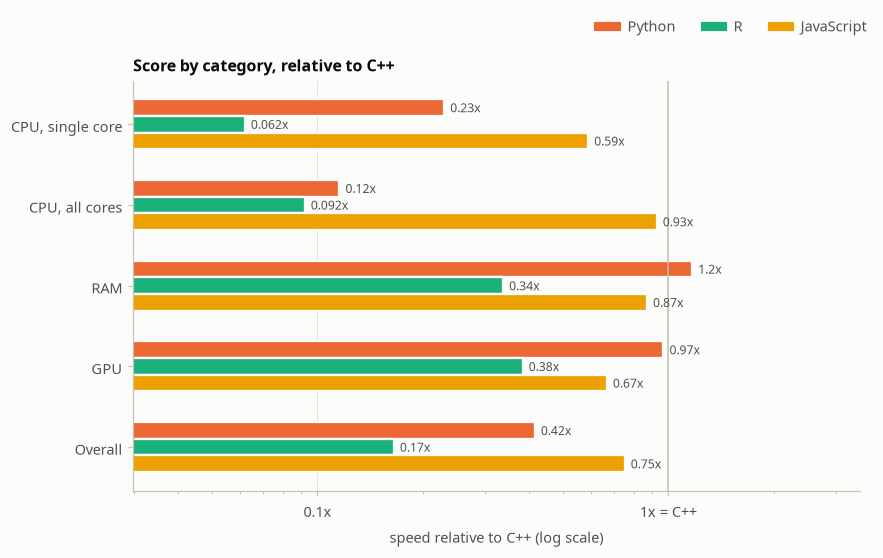

language,C++,Python,R,JavaScript
"CPU, single core",1x,0.23x,0.0621x,0.591x
"CPU, all cores",1x,0.116x,0.092x,0.927x
RAM,1x,1.17x,0.338x,0.869x
GPU,1x,0.968x,0.385x,0.668x
Overall,1x,0.416x,0.165x,0.751x


In [5]:
med = (data.groupby(["language", "category", "test", "style", "unit", "threads", "size"], as_index=False)
           .agg(seconds=("seconds", "median"), rate=("rate", "median"), reps=("rate", "size"),
                cv=("rate", lambda r: r.std(ddof=0) / r.mean() if len(r) > 1 else np.nan)))
best = med.loc[med.groupby(["language", "test"]).rate.idxmax()]
rate_by = best.pivot(index="test", columns="language", values="rate")
rate_by = rate_by.reindex([t for t in TEST_ORDER if t in rate_by.index])[langs]
ratio = rate_by.div(rate_by[REF], axis=0)
test_cat = tests_spec.set_index("test").category

def gmean(s):
    s = s.dropna()
    return float(np.exp(np.log(s).mean())) if len(s) else np.nan

cat_score = pd.DataFrame({c: ratio[test_cat.reindex(ratio.index) == c].apply(gmean) for c in CATEGORIES}).T
cat_score = cat_score.dropna(how="all")
overall = cat_score.apply(gmean)
scores = pd.concat([cat_score, overall.to_frame("overall").T])
labels = [CAT_TITLES.get(c, "Overall") for c in scores.index]

others = [l for l in langs if l != REF]   # REF is 1x by definition: drawn as the reference line
fig, ax = plt.subplots(figsize=(8, 0.5 * len(scores) * max(len(others), 2) / 2 + 1.3))
hbar_groups(ax, list(scores.index), others, lambda g, l: scores.loc[g, l],
            label_of=lambda g, l, v: f"{v:.2g}x", log=True)
ax.set_yticklabels(labels)
ax.set_xlim(right=max(2, np.nanmax(scores[others].values) * 3) if others else 2)
ax.axvline(1, color=AXIS, lw=1)
ax.set_xlabel(f"speed relative to {REF} (log scale)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"1x = {REF}" if v == 1 else f"{v:g}x"))
ax.set_title(f"Score by category, relative to {REF}")
finish_layout(fig, others); plt.show()

display(scores.rename(index=dict(zip(scores.index, labels))).map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-"))

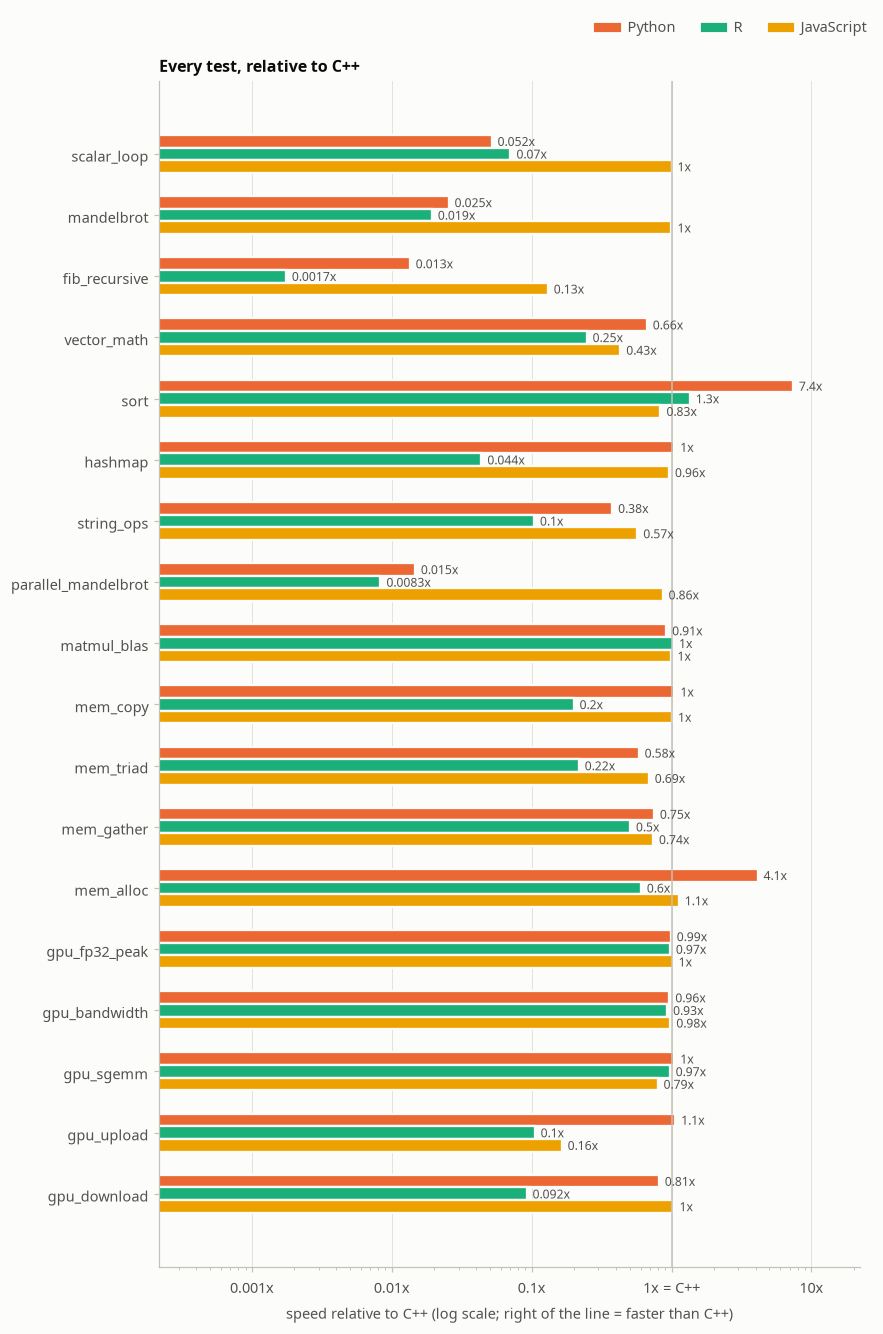

In [6]:
# Every test: speed relative to C++ (same data as above, before averaging)
fig, ax = plt.subplots(figsize=(8, 0.4 * len(ratio) * max(len(others), 2) / 2 + 1.3))
hbar_groups(ax, list(ratio.index), others, lambda g, l: ratio.loc[g, l],
            label_of=lambda g, l, v: f"{v:.2g}x", log=True)
ax.set_xlim(right=max(2, np.nanmax(ratio[others].values) * 3) if others else 2)
ax.axvline(1, color=AXIS, lw=1)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"1x = {REF}" if v == 1 else f"{v:g}x"))
ax.set_xlabel(f"speed relative to {REF} (log scale; right of the line = faster than {REF})")
ax.set_title(f"Every test, relative to {REF}")
finish_layout(fig, others); plt.show()

## 4. CPU, single core

Each panel is one test with its own unit. *loop* tests are plain code in each language;
*vectorized* / *builtin* tests hand the work to optimised library code (NumPy, R's C internals, the C++ standard library).

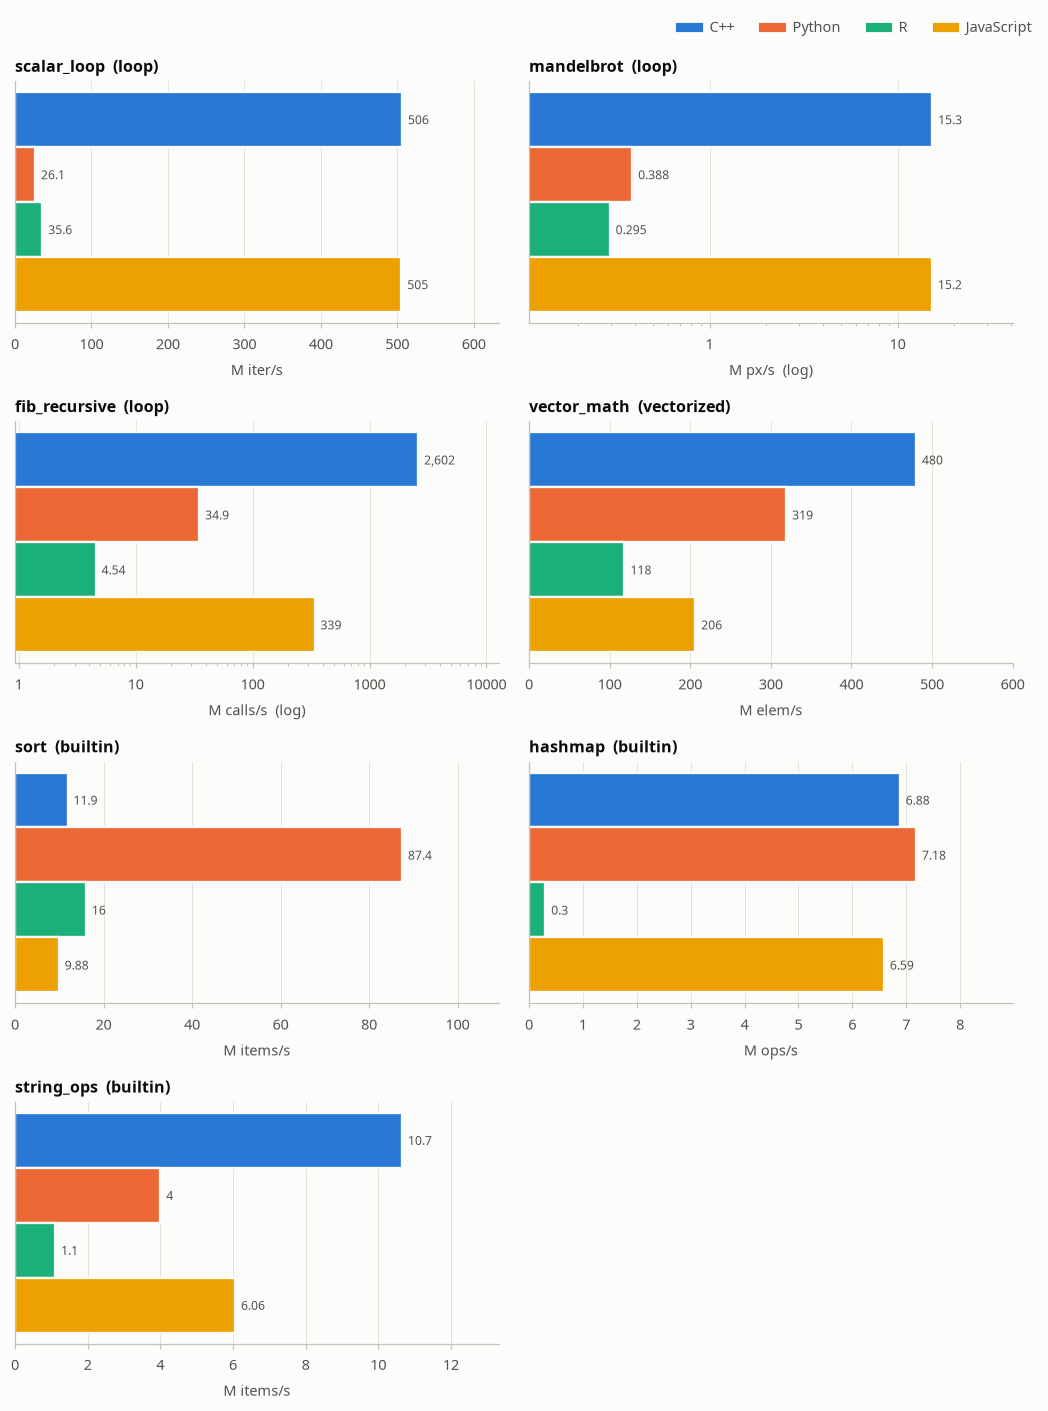

,unit,C++,Python,R,JavaScript,Python xC++,R xC++,JavaScript xC++
test,,,,,,,,
scalar_loop,M iter/s,506,26.1,35.6,505,0.0516,0.0704,0.998
mandelbrot,M px/s,15.3,0.388,0.295,15.2,0.0254,0.0193,0.998
fib_recursive,M calls/s,"2,602",34.9,4.54,339,0.0134,0.00175,0.13
vector_math,M elem/s,480,319,118,206,0.664,0.247,0.429
sort,M items/s,11.9,87.4,16,9.88,7.37,1.35,0.832
hashmap,M ops/s,6.88,7.18,0.3,6.59,1.04,0.0436,0.957
string_ops,M items/s,10.7,4,1.1,6.06,0.375,0.104,0.569


In [7]:
def test_panels(tests, ncols=2, log_if_spread=30):
    tests = [t for t in tests if t in rate_by.index]
    if not tests:
        print("No results for these tests.")
        return
    nrows = math.ceil(len(tests) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(9.5, 1.15 * nrows * max(len(langs), 2) / 2 + 0.9 * nrows),
                             squeeze=False)
    for ax, t in zip(axes.flat, tests):
        unit = tests_spec.set_index("test").unit[t]
        scale, label = DISPLAY[unit]
        vals = {l: rate_by.loc[t, l] / scale for l in langs if np.isfinite(rate_by.loc[t, l])}
        spread = max(vals.values()) / min(vals.values()) if vals else 1
        hbar_groups(ax, [t], langs, lambda g, l: vals.get(l, np.nan), log=spread > log_if_spread)
        style = tests_spec.set_index("test")["style"][t]
        ax.set_title(f"{t}  ({style})")
        ax.set_yticks([])
        ax.set_xlabel(label + ("  (log)" if spread > log_if_spread else ""))
    for ax in axes.flat[len(tests):]:
        ax.set_visible(False)
    finish_layout(fig, langs); plt.show()

def rate_table(tests):
    rows_ = []
    for t in [t for t in tests if t in rate_by.index]:
        scale, label = DISPLAY[tests_spec.set_index("test").unit[t]]
        rows_.append({"test": t, "unit": label, **{l: fmt(rate_by.loc[t, l] / scale) for l in langs},
                      **{f"{l} x{REF}": f"{ratio.loc[t, l]:.3g}" for l in langs if l != REF}})
    display(pd.DataFrame(rows_).set_index("test"))

single = [t for t in TEST_ORDER if test_cat[t] == "cpu_single"]
test_panels(single)
rate_table(single)

## 5. CPU, all cores

**Scaling**: the same Mandelbrot work split across 1 → all logical CPUs. Speedup = rate with *n* workers ÷ rate with 1.
The gray line is perfect scaling; beyond the physical cores, extra "threads" share a core (SMT) and the
laptop's power/thermal limit also caps the clock.

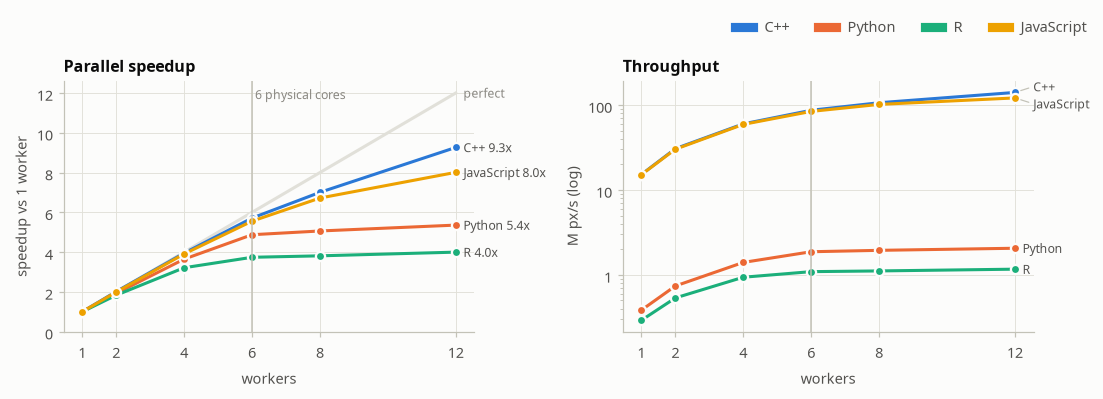

language,C++ speedup,Python speedup,R speedup,JavaScript speedup
threads,,,,
1,1.00,1.00,1.00,1.00
2,2.02,1.93,1.83,1.99
4,3.95,3.65,3.21,3.91
6,5.71,4.87,3.74,5.56
8,7.00,5.06,3.81,6.72
12,9.26,5.36,4.00,8.01


In [8]:
pm = med[med.test == "parallel_mandelbrot"].copy()
if pm.empty:
    print("No parallel_mandelbrot results.")
else:
    pm["speedup"] = pm.rate / pm.groupby("language").rate.transform(lambda r: r[pm.loc[r.index, "threads"] == 1].max())
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ax = axes[0]
    xs = sorted(pm.threads.unique())
    ax.plot(xs, xs, color=GRID, lw=2, zorder=1)
    end_label(ax, xs[-1], xs[-1], "perfect", color=MUTED)
    for l in langs:
        d = pm[pm.language == l].sort_values("threads")
        ax.plot(d.threads, d.speedup, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d.threads.iloc[-1], d.speedup.iloc[-1], f"{l} {d.speedup.iloc[-1]:.1f}x")
    ax.axvline(PHYS, color=AXIS, lw=1)
    ax.text(PHYS, 0.98, f" {PHYS} physical cores", transform=ax.get_xaxis_transform(), color=MUTED, fontsize=8, va="top")
    ax.set_xticks(xs); ax.set_xlabel("workers"); ax.set_ylabel("speedup vs 1 worker")
    ax.set_title("Parallel speedup")
    ax.set_ylim(0, max(xs) * 1.05)

    ax = axes[1]
    for l in langs:
        d = pm[pm.language == l].sort_values("threads")
        ax.plot(d.threads, d.rate / 1e6, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d.threads.iloc[-1], d.rate.iloc[-1] / 1e6, l)
    ax.set_yscale("log"); ax.set_xticks(xs); ax.set_xlabel("workers"); ax.set_ylabel("M px/s (log)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
    ax.axvline(PHYS, color=AXIS, lw=1)
    ax.set_title("Throughput")
    finish_layout(fig, langs); plt.show()
    display(pm.pivot(index="threads", columns="language", values="speedup")[langs].round(2)
              .rename(columns=lambda c: f"{c} speedup"))

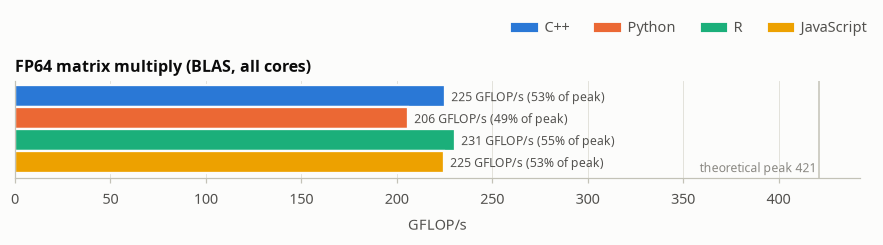

,size,threads,GFLOPs
language,,,
C++,4096,12,225.4
Python,4096,12,206.0
R,4096,12,230.6
JavaScript,4096,12,224.8


In [9]:
# Matrix multiply through BLAS (all cores) against the CPU's theoretical FP64 peak
mm = best[best.test == "matmul_blas"].set_index("language").reindex(langs)
fig, ax = plt.subplots(figsize=(8, 2.2))
hbar_groups(ax, ["matmul_blas"], langs, lambda g, l: mm.rate.get(l, np.nan) / 1e9,
            label_of=lambda g, l, v: f"{v:.0f} GFLOP/s" + (f" ({100 * v / PEAK['cpu_fp64_gflops']:.0f}% of peak)"
                                                           if np.isfinite(PEAK["cpu_fp64_gflops"]) else ""))
ax.set_yticks([]); ax.set_xlabel("GFLOP/s"); ax.set_title("FP64 matrix multiply (BLAS, all cores)")
if np.isfinite(PEAK["cpu_fp64_gflops"]):
    peak_line(ax, PEAK["cpu_fp64_gflops"], f"theoretical peak {PEAK['cpu_fp64_gflops']:.0f}")
    ax.set_xlim(0, PEAK["cpu_fp64_gflops"] * 1.05)
finish_layout(fig, langs); plt.show()
display(mm[["size", "threads", "rate"]].assign(GFLOPs=lambda d: (d.rate / 1e9).round(1)).drop(columns="rate"))

## 6. RAM

**Bandwidth** (copy and STREAM triad) against the theoretical peak of the memory. Python (NumPy) and R work on one
core; C++ also shows the triad on all physical / logical cores — a single core can't saturate the memory bus.

**Allocating big arrays**: on Linux, NumPy asks for 2 MB *huge pages* for large arrays (`madvise`), while plain C++
`new` and R use normal 4 KB pages. A kernel that gives huge pages only to programs that ask
(`/sys/kernel/mm/transparent_hugepage/enabled` = `madvise`) makes C++ and R take ~512× more page faults
when first touching new memory — that, not the language, is why NumPy wins `mem_alloc` there. Windows gives every
language 4 KB pages (its large pages need a special privilege) and zeroes each page on first touch.

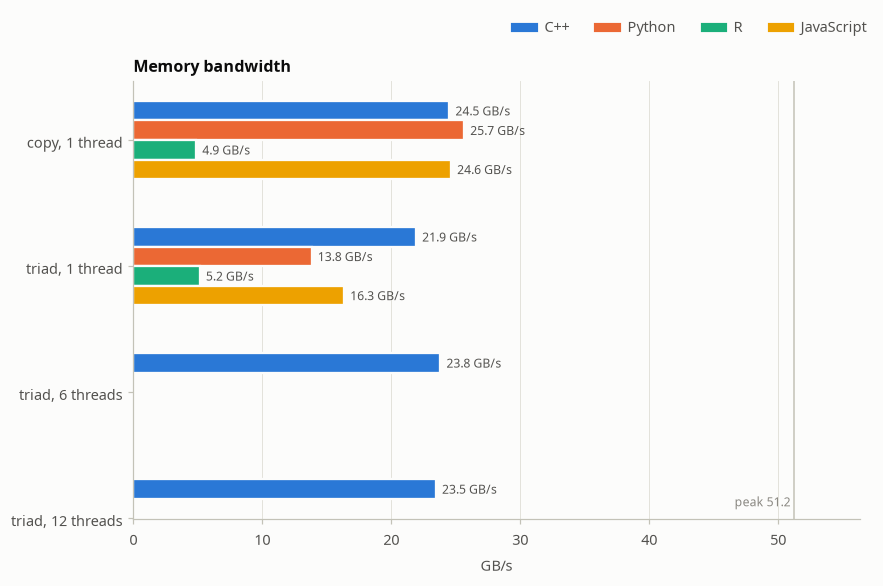

In [10]:
bw_groups = []
for t in ["mem_copy", "mem_triad"]:
    for th in sorted(med[(med.test == t)].threads.unique()):
        bw_groups.append((t, th))
bw = {(t, th, l): med[(med.test == t) & (med.threads == th) & (med.language == l)].rate.max() / 1e9
      for (t, th) in bw_groups for l in langs}
names = [f"{t.replace('mem_', '')}, {th} thread{'s' if th > 1 else ''}" for t, th in bw_groups]
if bw_groups:
    fig, ax = plt.subplots(figsize=(8, 0.5 * len(bw_groups) * max(len(langs), 2) / 2 + 1.3))
    hbar_groups(ax, names, langs, lambda g, l: bw[bw_groups[names.index(g)] + (l,)],
                label_of=lambda g, l, v: f"{v:.1f} GB/s")
    peak_line(ax, PEAK["ram_gbs"], f"peak {PEAK['ram_gbs']:.1f}")
    ax.set_xlim(0, PEAK["ram_gbs"] * 1.1)
    ax.set_xlabel("GB/s"); ax.set_title("Memory bandwidth")
    finish_layout(fig, langs); plt.show()

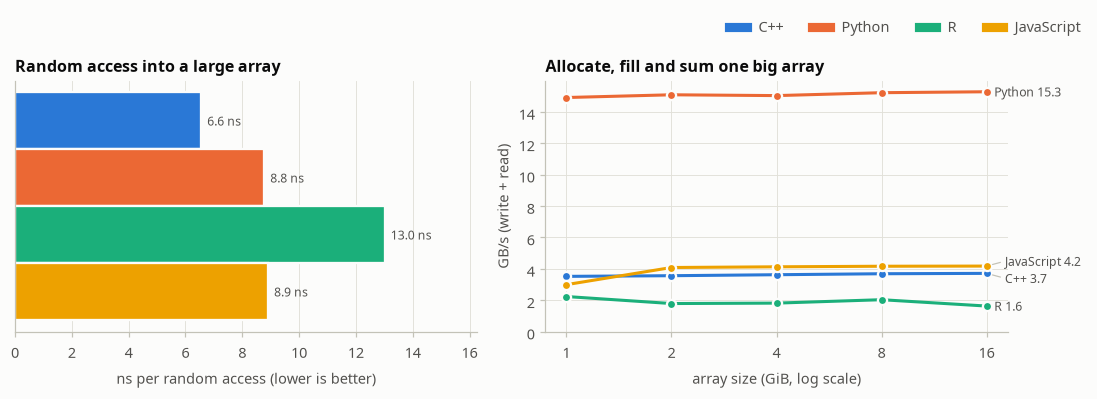

language,C++ seconds,Python seconds,R seconds,JavaScript seconds
GiB,,,,
1,0.61,0.14,0.96,0.72
2,1.20,0.28,2.40,1.05
4,2.37,0.57,4.72,2.08
8,4.66,1.13,8.44,4.12
16,9.25,2.25,21.06,8.22


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
g = best[best.test == "mem_gather"].set_index("language").reindex(langs)
ax = axes[0]
hbar_groups(ax, ["mem_gather"], langs, lambda _, l: 1e9 / g.rate.get(l, np.nan),
            label_of=lambda _, l, v: f"{v:.1f} ns")
ax.set_yticks([]); ax.set_xlabel("ns per random access (lower is better)")
ax.set_title("Random access into a large array")

ax = axes[1]
al = med[med.test == "mem_alloc"]
for l in langs:
    d = al[al.language == l].sort_values("size")
    if len(d):
        ax.plot(d["size"], d.rate / 1e9, marker="o", color=COLORS[l], label=l, markeredgecolor=SURFACE, markeredgewidth=1.5)
        end_label(ax, d["size"].iloc[-1], d.rate.iloc[-1] / 1e9, f"{l} {d.rate.iloc[-1] / 1e9:.1f}")
ax.set_xscale("log", base=2)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_xlabel("array size (GiB, log scale)"); ax.set_ylabel("GB/s (write + read)")
ax.set_ylim(bottom=0)
ax.set_title("Allocate, fill and sum one big array")
finish_layout(fig, langs); plt.show()
display(al.pivot(index="size", columns="language", values="seconds").reindex(columns=langs).round(2)
          .rename(columns=lambda c: f"{c} seconds").rename_axis("GiB"))

## 7. GPU (OpenCL; JavaScript: WebGPU)

C++, Python and R launch the same OpenCL kernels (`common/kernels.cl`); JavaScript runs their WebGPU translation
(`common/kernels.wgsl`, same arithmetic) through Google's Dawn (Vulkan on Linux, Direct3D 12 on Windows). Differences come from how each language and API
drive the GPU: launch overhead, buffer handling, and for R the conversion between R's 64-bit numbers and the GPU's 32-bit floats.
An integrated GPU shares system RAM, so its memory peak is the RAM peak; a discrete GPU's comes from `hardware.csv`.

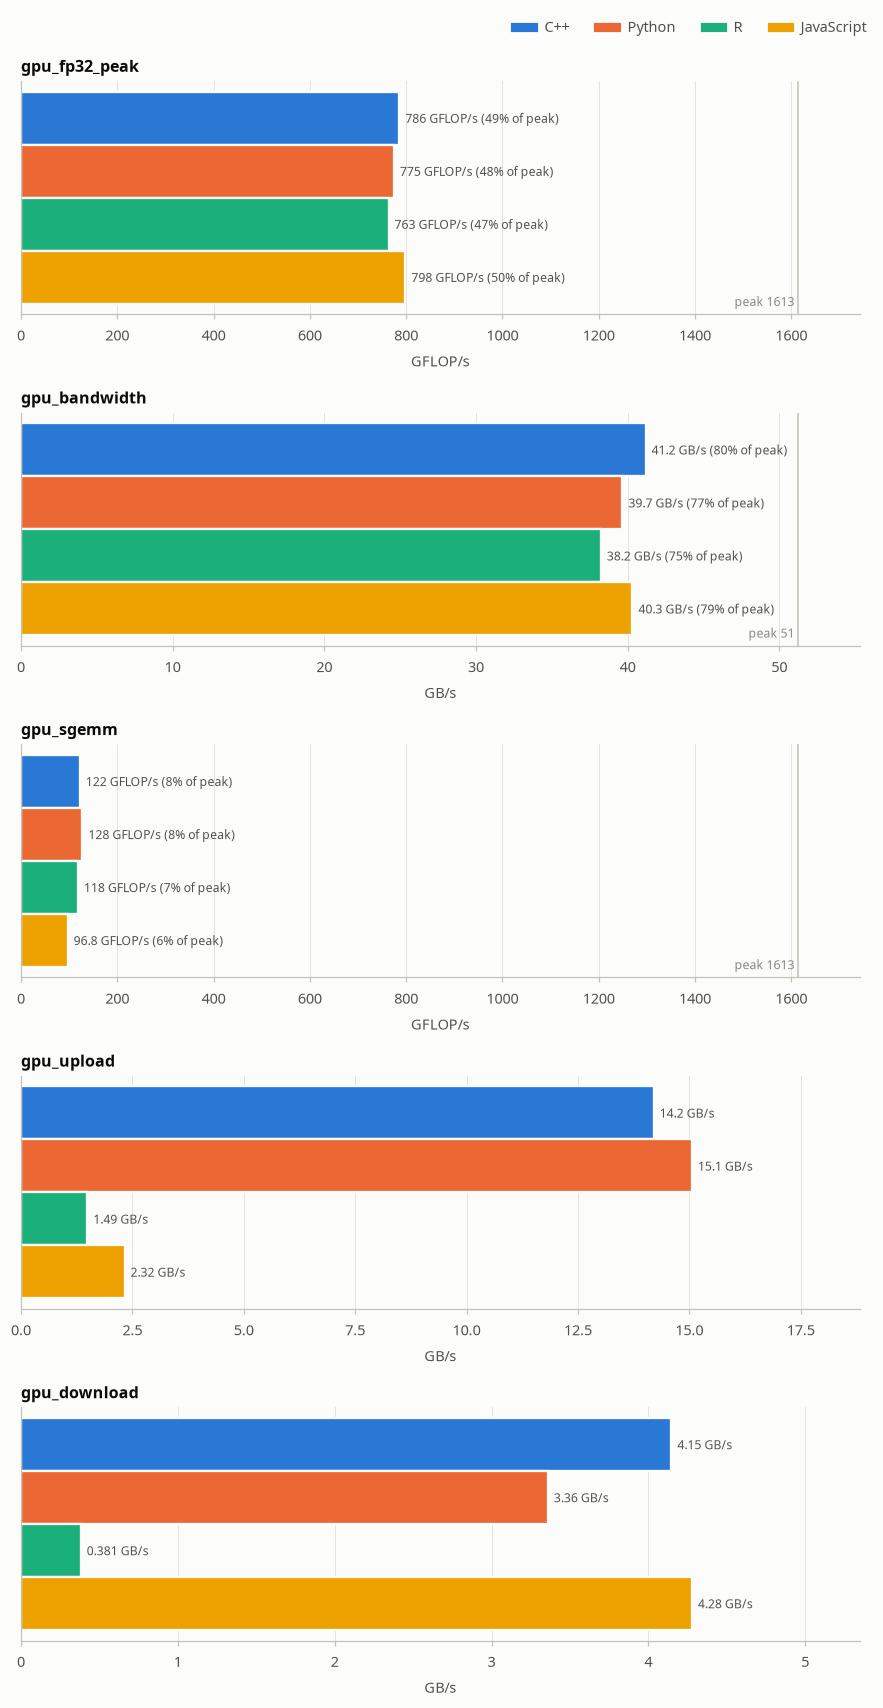

,unit,C++,Python,R,JavaScript,Python xC++,R xC++,JavaScript xC++
test,,,,,,,,
gpu_fp32_peak,GFLOP/s,786,775,763,798,0.986,0.971,1.02
gpu_bandwidth,GB/s,41.2,39.7,38.2,40.3,0.963,0.928,0.979
gpu_sgemm,GFLOP/s,122,128,118,96.8,1.04,0.968,0.793
gpu_upload,GB/s,14.2,15.1,1.49,2.32,1.06,0.105,0.164
gpu_download,GB/s,4.15,3.36,0.381,4.28,0.81,0.0918,1.03


In [12]:
gpu_tests = [t for t in TEST_ORDER if test_cat[t] == "gpu" and t in rate_by.index]
if not gpu_tests:
    print("No GPU results. Check `skipped` in the table of section 2 (OpenCL driver installed? RUSTICL_ENABLE=radeonsi?).")
else:
    gpu_langs = [l for l in langs if rate_by.loc[gpu_tests, l].notna().any()]
    missing = [l for l in langs if l not in gpu_langs]
    if missing:
        print("No GPU results for:", ", ".join(missing))
    fig, axes = plt.subplots(len(gpu_tests), 1, figsize=(8, 1.25 * len(gpu_tests) * max(len(gpu_langs), 2) / 2 + 0.6 * len(gpu_tests)),
                             squeeze=False)
    for ax, t in zip(axes.flat, gpu_tests):
        unit = tests_spec.set_index("test").unit[t]
        scale, label = DISPLAY[unit]
        peak = PEAK["gpu_fp32_gflops"] if unit == "FLOP" else (PEAK["gpu_mem_gbs"] if t == "gpu_bandwidth" else None)
        hbar_groups(ax, [t], gpu_langs, lambda _, l: rate_by.loc[t, l] / scale,
                    label_of=lambda _, l, v: f"{v:.3g} {label}" + (f" ({100 * v / peak:.0f}% of peak)" if peak and np.isfinite(peak) else ""))
        if peak is not None and np.isfinite(peak):
            peak_line(ax, peak, f"peak {peak:.0f}")
            ax.set_xlim(0, peak * 1.08)
        ax.set_yticks([]); ax.set_title(t); ax.set_xlabel(label)
    finish_layout(fig, gpu_langs); plt.show()
    rate_table(gpu_tests)

## 8. How much of the hardware each language can use

Best measured rate as a percentage of the theoretical peak (section 2). 100% is not reachable in practice —
for the CPU, the peak assumes every core at maximum boost, which laptop chips can't sustain.

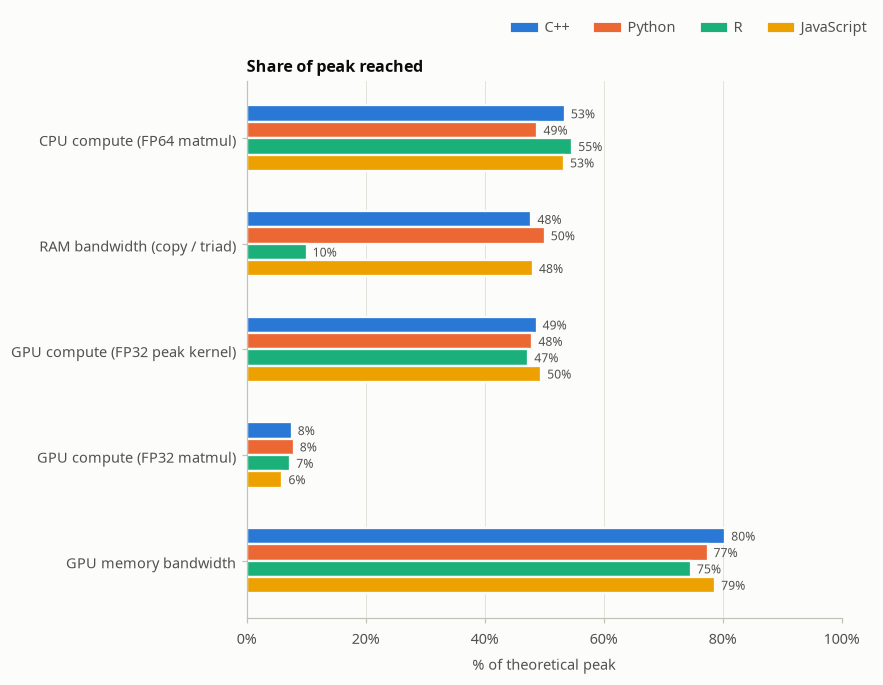

,C++ %,Python %,R %,JavaScript %
CPU compute (FP64 matmul),53.5,48.9,54.7,53.3
RAM bandwidth (copy / triad),47.9,50.1,10.1,48.1
GPU compute (FP32 peak kernel),48.7,48.0,47.3,49.5
GPU compute (FP32 matmul),7.6,7.9,7.3,6.0
GPU memory bandwidth,80.4,77.5,74.7,78.7


In [13]:
def best_rate(tests, l):
    vals = [rate_by.loc[t, l] for t in tests if t in rate_by.index and np.isfinite(rate_by.loc[t, l])]
    return max(vals) if vals else np.nan

UTIL = [("CPU compute (FP64 matmul)", ["matmul_blas"], 1e9, PEAK["cpu_fp64_gflops"]),
        ("RAM bandwidth (copy / triad)", ["mem_copy", "mem_triad"], 1e9, PEAK["ram_gbs"]),
        ("GPU compute (FP32 peak kernel)", ["gpu_fp32_peak"], 1e9, PEAK["gpu_fp32_gflops"]),
        ("GPU compute (FP32 matmul)", ["gpu_sgemm"], 1e9, PEAK["gpu_fp32_gflops"]),
        ("GPU memory bandwidth", ["gpu_bandwidth"], 1e9, PEAK["gpu_mem_gbs"])]
util = pd.DataFrame({l: {name: 100 * best_rate(ts, l) / s / p for name, ts, s, p in UTIL} for l in langs})
util = util.dropna(how="all")
fig, ax = plt.subplots(figsize=(8, 0.5 * len(util) * max(len(langs), 2) / 2 + 1.2))
hbar_groups(ax, list(util.index), langs, lambda g, l: util.loc[g, l], label_of=lambda g, l, v: f"{v:.0f}%")
ax.set_xlim(0, 100); ax.set_xlabel("% of theoretical peak")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Share of peak reached")
finish_layout(fig, langs); plt.show()
display(util.round(1).rename(columns=lambda c: f"{c} %"))

## 9. Consistency between repetitions

Coefficient of variation (standard deviation ÷ mean) of the repeated timings of each test. Under ~5% is steady;
large values usually mean thermal throttling, background activity or very short timings.

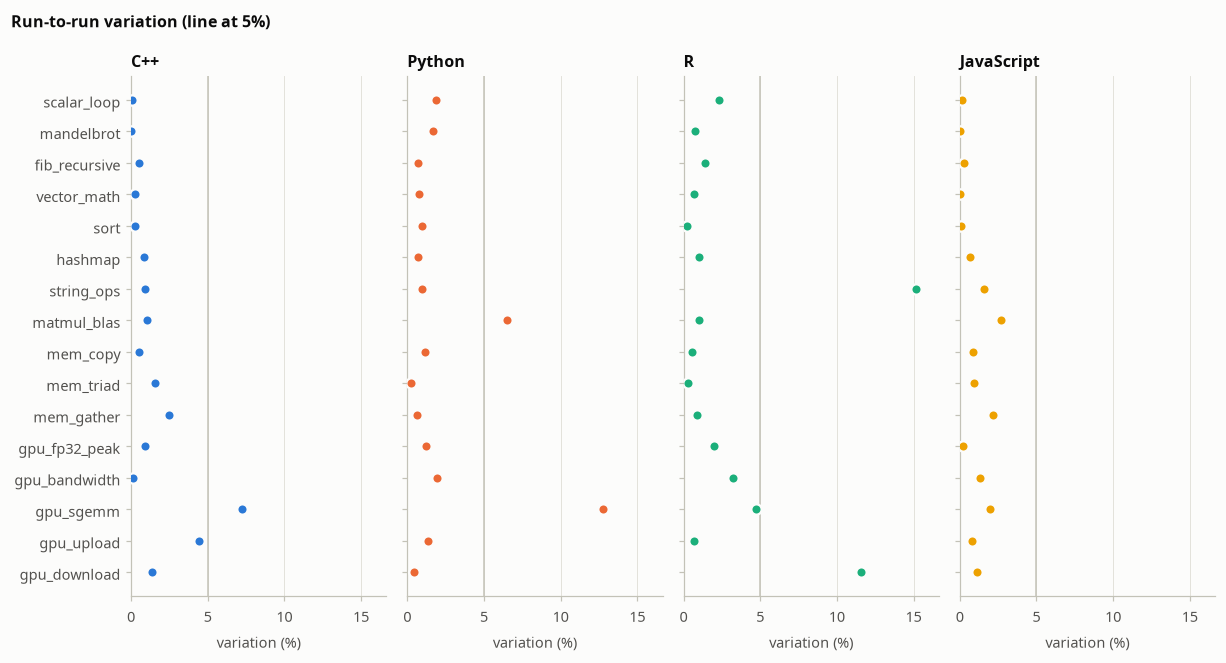

In [14]:
cv = med[med.cv.notna()].groupby(["test", "language"]).cv.max().unstack().reindex(columns=langs)
cv = cv.reindex([t for t in TEST_ORDER if t in cv.index])
if cv.empty:
    print("Only one repetition per test (e.g. verify mode) - nothing to show.")
else:
    xmax = max(10, np.nanmax(100 * cv.values) * 1.1)
    fig, axes = plt.subplots(1, len(langs), figsize=(2.4 * len(langs) + 1.6, 0.3 * len(cv) + 1.3),
                             sharey=True, squeeze=False)
    for ax, l in zip(axes.flat, langs):          # one panel per language (small multiples)
        ax.scatter(100 * cv[l], range(len(cv)), s=46, color=COLORS[l], edgecolors=SURFACE, linewidths=1.5, zorder=3)
        ax.axvline(5, color=AXIS, lw=1)
        ax.set_xlim(0, xmax); ax.set_title(l); ax.grid(axis="y", visible=False)
        ax.set_xlabel("variation (%)")
    axes[0, 0].set_yticks(range(len(cv)), cv.index); axes[0, 0].invert_yaxis()
    fig.suptitle("Run-to-run variation (line at 5%)", x=0.01, ha="left", fontweight="bold", fontsize=10.5, color=INK)
    plt.tight_layout(); plt.show()

## 10. Temperature and clock speed during the runs

From the sensor log written by `run_all.sh` (one sample per second). Shaded spans show which language was running.
A rising temperature with a falling clock is thermal throttling.

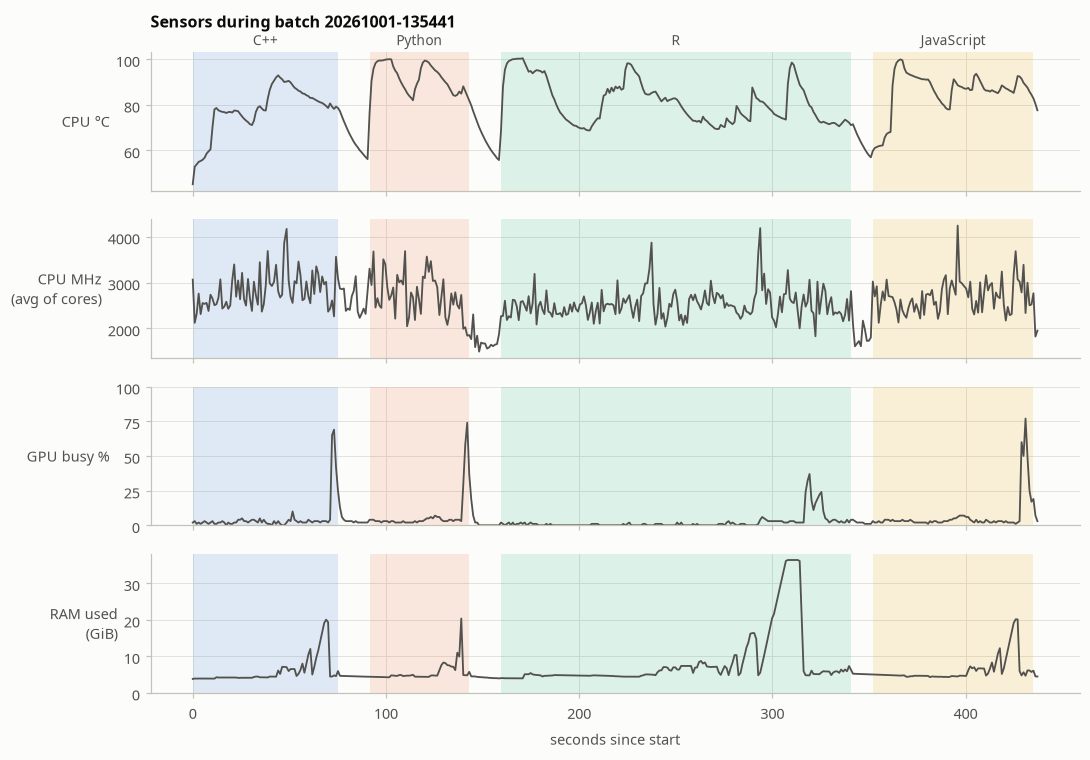

,seconds,max_cpu_temp_c,avg_cpu_mhz,max_gpu_busy_pct,max_ram_gib
phase,,,,,
C++,75.2,92.9,2830.1,69,20.0
JavaScript,83.1,99.9,2703.4,77,20.1
Python,51.6,100.0,2734.6,74,20.3
R,181.2,100.4,2524.5,37,36.4


In [15]:
folders = sorted(set(data.folder))
sensor_files = [Path(f) / f"sensors_{b}.csv" for f in folders for b in sorted(set(chosen.batch.dropna()))]
sensor_files = [p for p in sensor_files if p.exists()]
if not sensor_files:
    print("No sensor log for these runs (they were not started through run_all.sh).")
for path in sensor_files:
    s = pd.read_csv(path)
    if s.empty:
        continue
    s["t"] = s.time - s.time.iloc[0]
    panels = [("cpu_temp_c", "CPU °C", None), ("cpu_mhz_avg", "CPU MHz\n(avg of cores)", None),
              ("gpu_busy_pct", "GPU busy %", (0, 100)), ("mem_used_gib", "RAM used\n(GiB)", "zero")]
    panels = [(c, lab, lim) for c, lab, lim in panels if c in s and s[c].notna().any()]
    fig, axes = plt.subplots(len(panels), 1, figsize=(10, 1.6 * len(panels) + 0.6), sharex=True, squeeze=False)
    phase_runs = (s.phase != s.phase.shift()).cumsum()
    for ax, (col, lab, lim) in zip(axes.flat, panels):
        ax.plot(s.t, s[col], color=INK2, lw=1.2)
        if lim == "zero":
            ax.set_ylim(bottom=0)
        elif lim:
            ax.set_ylim(*lim)
        ax.set_ylabel(lab, rotation=0, ha="right", va="center")
        for _, seg in s.groupby(phase_runs):
            name = PHASE_NAMES.get(seg.phase.iloc[0])
            if name:
                ax.axvspan(seg.t.iloc[0], seg.t.iloc[-1], color=COLORS[name], alpha=0.14, lw=0)
    top = axes.flat[0]
    for _, seg in s.groupby(phase_runs):
        name = PHASE_NAMES.get(seg.phase.iloc[0])
        if name:
            top.text((seg.t.iloc[0] + seg.t.iloc[-1]) / 2, 1.02, name, transform=top.get_xaxis_transform(),
                     ha="center", va="bottom", color=INK2, fontsize=9)
    axes.flat[-1].set_xlabel("seconds since start")
    top.set_title(f"Sensors during batch {path.stem.replace('sensors_', '')}", pad=16)
    plt.tight_layout(); plt.show()
    summary = s[s.phase.isin(PHASE_NAMES)].groupby("phase").agg(
        seconds=("t", lambda t: t.max() - t.min()), max_cpu_temp_c=("cpu_temp_c", "max"),
        avg_cpu_mhz=("cpu_mhz_avg", "mean"), max_gpu_busy_pct=("gpu_busy_pct", "max"), max_ram_gib=("mem_used_gib", "max"))
    display(summary.rename(index=PHASE_NAMES).round(1))

## 11. Key findings
Generated from the numbers above.

In [16]:
lines = []
others = [l for l in langs if l != REF]
for l in others:
    lines.append(f"- **{l} overall: {overall[l]:.2g}× {REF}** "
                 + "(" + ", ".join(f"{CAT_TITLES[c]} {cat_score.loc[c, l]:.2g}×" for c in cat_score.index if np.isfinite(cat_score.loc[c, l])) + ").")
    r = ratio[l].dropna()
    if len(r):
        slow, fast = r.idxmin(), r.idxmax()
        lines.append(f"  - Biggest gap: `{slow}` at {r[slow]:.2g}× ({1 / r[slow]:.0f}× slower). "
                     f"Closest: `{fast}` at {r[fast]:.2g}×.")
loop_tests = [t for t in ratio.index if tests_spec.set_index("test")["style"][t] == "loop"]
lib_tests = [t for t in ratio.index if tests_spec.set_index("test")["style"][t] in ("vectorized", "builtin", "blas")
             and test_cat[t] != "gpu"]
for l in others:
    a, b = gmean(ratio.loc[loop_tests, l]), gmean(ratio.loc[lib_tests, l])
    if np.isfinite(a) and np.isfinite(b):
        gain = (f"handing work to optimised libraries is worth ~{b / a:.0f}×." if b / a >= 1.5 else
                "plain loops are already about as fast as library code (they are compiled, e.g. by a JIT).")
        lines.append(f"- {l}: plain loops run at {a:.2g}× {REF}, library / vectorized code at {b:.2g}× — {gain}")
if not pm.empty:
    sp = pm.loc[pm.groupby("language").speedup.idxmax()].set_index("language")
    lines.append("- Parallel speedup (best): " + ", ".join(f"{l} {sp.speedup[l]:.1f}× with {int(sp.threads[l])} workers" for l in langs if l in sp.index)
                 + f" on {PHYS} physical cores.")
for name in util.index:
    row = util.loc[name].dropna()
    if len(row):
        lines.append(f"- {name}: best {row.max():.0f}% of peak ({row.idxmax()}).")
display(Markdown("\n".join(lines)))

- **Python overall: 0.42× C++** (CPU, single core 0.23×, CPU, all cores 0.12×, RAM 1.2×, GPU 0.97×).
  - Biggest gap: `fib_recursive` at 0.013× (75× slower). Closest: `sort` at 7.4×.
- **R overall: 0.17× C++** (CPU, single core 0.062×, CPU, all cores 0.092×, RAM 0.34×, GPU 0.38×).
  - Biggest gap: `fib_recursive` at 0.0017× (573× slower). Closest: `sort` at 1.3×.
- **JavaScript overall: 0.75× C++** (CPU, single core 0.59×, CPU, all cores 0.93×, RAM 0.87×, GPU 0.67×).
  - Biggest gap: `fib_recursive` at 0.13× (8× slower). Closest: `mem_alloc` at 1.1×.
- Python: plain loops run at 0.026× C++, library / vectorized code at 1.1× — handing work to optimised libraries is worth ~44×.
- R: plain loops run at 0.013× C++, library / vectorized code at 0.3× — handing work to optimised libraries is worth ~23×.
- JavaScript: plain loops run at 0.51× C++, library / vectorized code at 0.78× — handing work to optimised libraries is worth ~2×.
- Parallel speedup (best): C++ 9.3× with 12 workers, Python 5.4× with 12 workers, R 4.0× with 12 workers, JavaScript 8.0× with 12 workers on 6 physical cores.
- CPU compute (FP64 matmul): best 55% of peak (R).
- RAM bandwidth (copy / triad): best 50% of peak (Python).
- GPU compute (FP32 peak kernel): best 50% of peak (JavaScript).
- GPU compute (FP32 matmul): best 8% of peak (Python).
- GPU memory bandwidth: best 80% of peak (C++).

## 12. Compare machines

Every machine in `results/` (newest run of each language, same mode). Speeds are relative to the machine analysed
above (`MACHINE`): 2× means twice as fast for that language. Results are only comparable when machines ran the same
version of the tests (`suite_tests_sha` in the table).

In [17]:
cmp_runs = runs[runs["mode"] == mode].sort_values("started").groupby(["machine", "language"]).tail(1)
machines = sorted(set(cmp_runs.machine), key=lambda m: (m != machine, m))   # analysed machine first
if len(machines) < 2:
    print(f"Only one machine ({machine}) has '{mode}' results so far. Run ./run_all.sh on another computer, "
          "then add its results/<machine>/ folder here (for example through the git repository).")
else:
    hw_keys = ["product", "cpu", "physical_cores", "cpu_max_mhz", "ram_gib", "ram_type", "ram_speed_mts", "gpus", "os", "suite_tests_sha"]
    display(pd.DataFrame({m: {k: system_of(m).get(k, "") or "-" for k in hw_keys} for m in machines}))
    shas = {system_of(m).get("suite_tests_sha") for m in machines} - {None, ""}
    if len(shas) > 1:
        print("Warning: machines ran different versions of tests.csv / kernels (suite_tests_sha differs); "
              "their rates may not be comparable.")

    cmp = rows[rows.run_key.isin(cmp_runs.run_key)]
    cmed = cmp.groupby(["machine", "language", "test", "threads", "size"], as_index=False).rate.median()
    cbest = cmed.groupby(["machine", "language", "test"]).rate.max().unstack("machine")[machines]
    rel = cbest.div(cbest[machine], axis=0).reset_index()           # speed vs the analysed machine
    rel["category"] = rel.test.map(test_cat)
    by_cat = rel.groupby(["language", "category"])[machines].agg(gmean)
    overall_m = by_cat.groupby(level="language").agg(gmean)
    cl = [l for l in LANGS if l in overall_m.index]

    fig, axes = plt.subplots(1, len(cl), figsize=(2.9 * len(cl) + 1.8, 0.45 * len(machines) + 1.5),
                             sharey=True, squeeze=False)
    y = np.arange(len(machines))
    for ax, l in zip(axes.flat, cl):                # one panel per language (colour = language)
        vals = overall_m.loc[l, machines].astype(float)
        ax.barh(y, vals, height=0.5, color=COLORS[l], edgecolor=SURFACE, linewidth=1.5)
        for yi, v in zip(y, vals):
            if np.isfinite(v):
                ax.text(v, yi, f"  {v:.2g}x", va="center", fontsize=8, color=INK2)
        ax.set_xscale("log"); ax.axvline(1, color=AXIS, lw=1); ax.margins(x=0.35)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:g}x"))
        ax.set_title(l); ax.grid(axis="y", visible=False)
    axes[0, 0].set_yticks(y, machines); axes[0, 0].invert_yaxis()
    fig.suptitle(f"Overall speed of each machine, relative to {machine} (log scale)",
                 x=0.01, ha="left", fontweight="bold", fontsize=10.5, color=INK)
    plt.tight_layout(); plt.show()

    display(overall_m[machines].map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-")
              .rename_axis(f"overall vs {machine}"))
    display(by_cat[machines].map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-")
              .rename(index=CAT_TITLES, level="category"))

    # How far each language is from C++ on each machine (does the gap change with the hardware?)
    gap = {}
    for m in machines:
        b = cbest[m].unstack("language")
        if "C++" not in b:
            continue
        r = b.div(b["C++"], axis=0)
        cat = pd.DataFrame({c: r[r.index.map(test_cat) == c].apply(gmean) for c in CATEGORIES}).T.dropna(how="all")
        gap[m] = cat.apply(gmean)
    if gap:
        display(pd.DataFrame(gap)[list(gap)].reindex(LANGS).dropna(how="all")
                  .map(lambda v: f"{v:.3g}x" if np.isfinite(v) else "-").rename_axis("overall vs C++ on the same machine"))

Only one machine (dell-inc-inspiron-14-7425-2-in-1) has 'full' results so far. Run ./run_all.sh on another computer, then add its results/<machine>/ folder here (for example through the git repository).
